# TinyMWAMNet · Notebook 01 — Data, leakage audit and the MWAMNet teacher

In [ ]:
#@title 1 · Install packages
import importlib.metadata as md, subprocess, sys, os
def _v(p):
    try:
        return md.version(p)
    except md.PackageNotFoundError:
        return None
tfv = _v("tensorflow")
pk = []
if tfv is None:
    pk.append("tensorflow[and-cuda]==2.21.0"); tfv = "2.21.0"
mm = ".".join(tfv.split(".")[:2])
pk += [f"tf_keras~={mm}.0", "setuptools<81"] + ['tensorflow-model-optimization==0.8.1', 'kagglehub', 'imagehash', 'statsmodels', 'pyyaml']
if not os.environ.get("TMN_SKIP_PIP"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pk, check=True)
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # tf_keras (Keras 2) is required by TF-MOT for QAT
print("TensorFlow", tfv, "| installed:", pk)

TensorFlow 2.20.0 | installed: ['tf_keras~=2.20.0', 'setuptools<81', 'tensorflow-model-optimization==0.8.1', 'kagglehub', 'imagehash', 'statsmodels', 'pyyaml']


In [ ]:
%%writefile /content/tmn_common.py
"""
TinyMWAMNet — shared utilities for all Colab notebooks.

"""
import os, sys, json, math, time, glob, hashlib, random, gc, re, subprocess, shutil
from concurrent.futures import ThreadPoolExecutor
import numpy as np

# ---------------------------------------------------------------------------
# 1. Configuration (pre-specified; nothing here is tuned on shifted data)
# ---------------------------------------------------------------------------
CFG = dict(
    # Kaggle dataset identifiers
    DIN_ID="alik05/forest-fire-dataset",                 # in-domain (paper 1)
    WILD_ID="elmadafri/the-wildfire-dataset",            # Shift-1 (anticipated)
    DFIRE_ID="sayedgamal99/smoke-fire-detection-yolo",   # Shift-2 (unanticipated, CC0)
    IMG=224, SEED=42, SEEDS=[42, 43, 44, 45, 46], VAL_FRAC=0.20,
    # teacher (identical to paper 1)
    TEACHER_COPIES=4, HUE=0.10, L2=0.01, DROPOUT=0.5, LR=1e-4, WD=1e-4,
    EPOCHS=100, BATCH=32, PATIENCE=15,
    # augmentation pools for students
    STD_COPIES=8,          # paper-1 augmentation; copies 1-4 are identical to paper 1
    CONF_COPIES=4,         # confounder-aware copies (CAD)
    # students
    KD_T=2.0, KD_ALPHA=0.5,
    ST_BATCH=64, ST_WARM_EPOCHS=3, ST_EPOCHS=25, ST_LR_WARM=1e-3, ST_LR=3e-4,
    ST_WD=1e-4, ST_DROPOUT=0.2, QAT_EPOCHS=5, QAT_LR=5e-5,
    CALIB_N=256,
    # leakage audit
    PHASH_MAX_DIST=6,
    # weight-only bit-width sweep
    WBITS=[8, 6, 5, 4, 3],
    TEST_MODE=bool(int(os.environ.get("TMN_TEST_MODE", "0"))),
)

MAIN_STUDENT = ("mnv3s", 1.0, 128)          # TinyMWAMNet-S
FAMILY = [("mnv1", 0.25, 96),                # TinyMWAMNet-XS (MLPerf Tiny VWW size)
          ("mnv3s", 1.0, 96), ("mnv3s", 1.0, 160), ("mnv2", 0.35, 128)]
REGIMES = {  # name: (use KD?, pool kind)
    "CE-std": (False, "std"), "CE-conf": (False, "conf"),
    "KD-std": (True, "std"), "CAD": (True, "conf"),   # CAD = KD + confounder aug
}
EVALSETS = ("din", "wild", "dfire")
EVAL_NAMES = {"din": "In-domain test", "wild": "Shift-1 (The Wildfire Dataset)",
              "dfire": "Shift-2 (D-Fire)"}

if CFG["TEST_MODE"]:
    CFG.update(SEEDS=[42, 43], EPOCHS=3, PATIENCE=2, STD_COPIES=2, CONF_COPIES=2,
               TEACHER_COPIES=1, ST_WARM_EPOCHS=1, ST_EPOCHS=1, QAT_EPOCHS=1,
               CALIB_N=8, WBITS=[8, 4])
    FAMILY = [("mnv1", 0.25, 96)]

IMGEXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def log(*a):
    print(time.strftime("[%H:%M:%S]"), *a, flush=True)


# ---------------------------------------------------------------------------
# 2. Paths (Google Drive if mounted, else local)
# ---------------------------------------------------------------------------
def setup_paths():
    root = os.environ.get("TMN_ROOT")
    if not root:
        root = ("/content/drive/MyDrive/TinyMWAMNet"
                if os.path.isdir("/content/drive/MyDrive") else "/content/TinyMWAMNet")
    P = {k: os.path.join(root, k) for k in
         ["data", "features", "models", "results", "preds", "figures", "tflite", "logs"]}
    P["root"] = root
    P["tmp"] = os.environ.get("TMN_TMP", "/content/tmn_tmp")
    for v in P.values():
        os.makedirs(v, exist_ok=True)
    return P


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o))


def load_json(path):
    with open(path) as f:
        return json.load(f)


def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        import tf_keras as keras
        keras.utils.set_random_seed(seed)
    except Exception:
        pass


# ---------------------------------------------------------------------------
# 3. Dataset download and discovery
# ---------------------------------------------------------------------------
def kaggle_download(kid):
    """kagglehub download; TMN_FAKE_DATA=<dir> redirects to local copies (testing)."""
    fake = os.environ.get("TMN_FAKE_DATA")
    if fake:
        return os.path.join(fake, kid.replace("/", "__"))
    import kagglehub
    return kagglehub.dataset_download(kid)


def _load_one(p, S, draft):
    from PIL import Image
    try:
        with Image.open(p) as im:
            if draft:
                im.draft("RGB", (S * 2, S * 2))       # fast DCT-scaled JPEG decode
            return np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR))
    except Exception as e:
        print("   unreadable, stored as black frame:", os.path.basename(p), e)
        return np.zeros((S, S, 3), np.uint8)


def load_images(paths, S=224, draft=False, workers=8):
    out = np.zeros((len(paths), S, S, 3), np.uint8)
    with ThreadPoolExecutor(workers) as ex:
        for i, a in enumerate(ex.map(lambda p: _load_one(p, S, draft), paths)):
            out[i] = a
    return out


def discover_din(root):
    """Forest Fire Dataset (alik05). Identical file lists and split to paper 1."""
    from sklearn.model_selection import train_test_split
    base = glob.glob(os.path.join(root, "**", "Forest Fire Dataset"), recursive=True)[0]
    tr_dir, te_dir = os.path.join(base, "Training"), os.path.join(base, "Testing")
    pool_p, pool_y = [], []
    for cls, lab in (("nofire", 0), ("fire", 1)):
        fs = sorted(glob.glob(os.path.join(tr_dir, cls, "*.jpg")))
        pool_p += fs; pool_y += [lab] * len(fs)
    pool_y = np.array(pool_y, np.int32)
    te_p = sorted(glob.glob(os.path.join(te_dir, "*.jpg")))
    te_y = np.array([0 if os.path.basename(p).lower().startswith("nofire") else 1
                     for p in te_p], np.int32)
    tr_p, va_p, tr_y, va_y = train_test_split(pool_p, pool_y, test_size=CFG["VAL_FRAC"],
                                              random_state=CFG["SEED"], stratify=pool_y)
    return dict(tr_p=list(tr_p), va_p=list(va_p), te_p=te_p,
                tr_y=np.array(tr_y, np.int32), va_y=np.array(va_y, np.int32), te_y=te_y)


def discover_wild(root):
    """The Wildfire Dataset: labels from 'fire'/'nofire' folders, subclass = leaf folder."""
    recs = []
    for dp, dn, fn in os.walk(root):
        dn.sort()
        parts = [p.lower() for p in dp[len(root):].split(os.sep) if p]
        if any(p == "nofire" for p in parts):
            lab = 0
        elif any(p == "fire" for p in parts):
            lab = 1
        else:
            continue
        sub = parts[-1] if parts[-1] not in ("fire", "nofire") else "unspecified"
        for f in sorted(fn):
            if os.path.splitext(f)[1].lower() in IMGEXT:
                recs.append((os.path.join(dp, f), lab, sub))
    recs.sort(key=lambda r: r[0])
    return dict(paths=[r[0] for r in recs], y=np.array([r[1] for r in recs], np.int32),
                sub=np.array([r[2] for r in recs]))


def _yolo_names(root):
    try:
        import yaml
    except Exception:
        return None
    for y in glob.glob(os.path.join(root, "**", "*.yaml"), recursive=True):
        try:
            d = yaml.safe_load(open(y))
            names = d.get("names") if isinstance(d, dict) else None
            if isinstance(names, dict):
                names = [names[k] for k in sorted(names)]
            if names:
                return [str(n).lower() for n in names]
        except Exception:
            pass
    return None


def discover_dfire(root, prefer=("test",)):
    """D-Fire (YOLO format). fire = >=1 fire box; no-fire = no boxes; smoke-only excluded."""
    lab_dirs = [d for d in glob.glob(os.path.join(root, "**", "labels"), recursive=True)
                if os.path.isdir(os.path.join(os.path.dirname(d), "images"))]
    splits = {os.path.basename(os.path.dirname(d)).lower(): d for d in lab_dirs}
    print("D-Fire splits found:", {k: len(os.listdir(v)) for k, v in splits.items()})
    chosen = [splits[k] for k in prefer if k in splits] or list(splits.values())
    names = _yolo_names(root)
    if names and "fire" in names:
        fire_id = names.index("fire")
    else:
        fire_id = 1                                   # D-Fire convention: 0 smoke, 1 fire
    recs, stats = [], dict(fire=0, none=0, smoke_only=0)
    only = {}
    for ld in chosen:
        imd = os.path.join(os.path.dirname(ld), "images")
        imgs = {os.path.splitext(f)[0]: os.path.join(imd, f) for f in os.listdir(imd)
                if os.path.splitext(f)[1].lower() in IMGEXT}
        for stem, ip in sorted(imgs.items()):
            lf = os.path.join(ld, stem + ".txt")
            cls = []
            if os.path.exists(lf):
                cls = [int(float(l.split()[0])) for l in open(lf) if l.strip()]
            s = set(cls)
            if len(s) == 1:
                only[next(iter(s))] = only.get(next(iter(s)), 0) + 1
            if fire_id in s:
                recs.append((ip, 1, "fire+smoke" if len(s) > 1 else "fire_only")); stats["fire"] += 1
            elif not s:
                recs.append((ip, 0, "none")); stats["none"] += 1
            else:
                stats["smoke_only"] += 1
    print("D-Fire class names:", names, "-> fire id =", fire_id,
          "| images with a single class:", only, "| kept:", stats)
    if only and len(only) == 2 and only.get(fire_id, 0) > only.get(1 - fire_id, 0):
        print("WARNING: the class treated as 'fire' is the more frequent single class; in "
              "D-Fire smoke-only images outnumber fire-only images ~5:1. Check the mapping!")
    return dict(paths=[r[0] for r in recs], y=np.array([r[1] for r in recs], np.int32),
                sub=np.array([r[2] for r in recs]), stats=stats, fire_id=fire_id)


# ---------------------------------------------------------------------------
# 4. Augmentation (paper-1 recipe) and confounder-aware augmentation (CAD)
# ---------------------------------------------------------------------------
def _tf():
    import tensorflow as tf
    return tf


def std_aug_block(X, copy_idx, indices=None, batch=256):
    """Paper-1 augmentation, seeds s=[i, c*7919+13]; returns uint8 array.
    Copies 1..4 are bit-identical to the paper-1 teacher training pool."""
    tf = _tf()
    idx = np.arange(len(X)) if indices is None else np.asarray(indices)
    c = int(copy_idx)

    def aug_one(x_u8, i):
        s = tf.stack([tf.cast(i, tf.int32), tf.constant(c * 7919 + 13, tf.int32)])
        im = tf.cast(x_u8, tf.float32) / 255.0
        im = tf.image.stateless_random_flip_left_right(im, s)
        im = tf.image.stateless_random_brightness(im, 0.10, s + 1)
        im = tf.image.stateless_random_contrast(im, 0.9, 1.1, s + 2)
        im = tf.image.stateless_random_saturation(im, 0.9, 1.1, s + 3)
        im = tf.image.stateless_random_hue(im, CFG["HUE"], s + 4)
        im = tf.clip_by_value(im, 0.0, 1.0)
        im = tf.image.stateless_random_jpeg_quality(im, 75, 100, s + 5)
        return tf.cast(tf.round(im * 255.0), tf.uint8)

    ds = tf.data.Dataset.from_tensor_slices((X[idx], idx.astype(np.int32)))
    ds = ds.map(aug_one, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True).batch(batch)
    with tf.device("/CPU:0"):
        return np.concatenate([b.numpy() for b in ds]) if len(idx) else X[:0].copy()


# ---- confounder transforms (NumPy/SciPy only, deterministic per image) ----
def _warm_cast(im, r):
    """Sunset / golden-hour illumination: channel gains plus a warm sky gradient."""
    g = np.array([r.uniform(1.05, 1.35), r.uniform(0.92, 1.08), r.uniform(0.60, 0.88)])
    out = im * g
    H = im.shape[0]
    ramp = np.linspace(1.0, 0.0, H)[:, None, None] ** r.uniform(0.8, 2.0)
    a = r.uniform(0.15, 0.45) * ramp
    tint = np.array([1.0, r.uniform(0.45, 0.65), r.uniform(0.10, 0.30)])
    return out * (1 - a) + tint * a


def _foliage(im, r):
    """Autumn foliage: rotate green hues towards yellow/red, boost saturation.
    Pure NumPy (matplotlib's HSV conversion); no OpenCV dependency."""
    from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
    hsv = rgb_to_hsv(np.clip(im, 0.0, 1.0).astype(np.float64))
    h = hsv[..., 0] * 360.0                                         # hue in degrees
    green = (h > 55) & (h < 170)
    h[green] = (h[green] - r.uniform(40, 95)) % 360.0
    hsv[..., 0] = h / 360.0
    hsv[..., 1] = np.clip(hsv[..., 1] * np.where(green, r.uniform(1.0, 1.3), 1.0), 0, 1)
    return hsv_to_rgb(hsv)


def _haze(im, r):
    """Fog / haze via the atmospheric scattering model I = J t + A (1 - t)."""
    H = im.shape[0]
    t0 = r.uniform(0.45, 0.85)
    grad = np.linspace(r.uniform(0.0, 0.25), 0.0, H)[:, None, None]  # denser near the top
    t = np.clip(t0 - grad, 0.25, 1.0)
    A = r.uniform(0.75, 0.95) * np.array([1.0, 1.0, r.uniform(0.95, 1.05)])
    return im * t + A * (1 - t)


def _glare(im, r):
    """Sun glare / specular reflection: additive warm Gaussian blob."""
    H, W = im.shape[:2]
    cy, cx = r.uniform(0.05, 0.95) * H, r.uniform(0.05, 0.95) * W
    s = r.uniform(0.08, 0.25) * H
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s))[..., None]
    col = np.array([1.0, r.uniform(0.80, 0.95), r.uniform(0.50, 0.75)])
    return im + r.uniform(0.3, 0.8) * g * col


def _line_kernel(L, angle_deg):
    """Normalised L x L linear motion-blur kernel at the given angle (bilinear splatting)."""
    k = np.zeros((L, L), np.float64)
    c = (L - 1) / 2.0
    t = np.linspace(-c, c, 8 * L)
    a = np.deg2rad(angle_deg)
    xs, ys = c + t * np.cos(a), c - t * np.sin(a)
    x0, y0 = np.floor(xs).astype(int), np.floor(ys).astype(int)
    fx, fy = xs - x0, ys - y0
    for dx, dy, w in ((0, 0, (1 - fx) * (1 - fy)), (1, 0, fx * (1 - fy)),
                      (0, 1, (1 - fx) * fy), (1, 1, fx * fy)):
        np.add.at(k, (np.clip(y0 + dy, 0, L - 1), np.clip(x0 + dx, 0, L - 1)), w)
    return k / k.sum()


def _motion(im, r):
    """Camera/platform motion blur: linear kernel of random length and angle.
    SciPy convolution with reflected borders; no OpenCV dependency."""
    from scipy.ndimage import convolve
    L = int(r.choice([5, 7, 9, 11, 13, 15]))
    k = _line_kernel(L, r.uniform(0, 180))
    return np.stack([convolve(im[..., ch].astype(np.float64), k, mode="reflect")
                     for ch in range(im.shape[-1])], axis=-1)


def _lowlight(im, r):
    """Dusk / low light: gamma darkening, slight blue shift and sensor noise."""
    out = im ** r.uniform(1.6, 2.6)
    out = out * np.array([r.uniform(0.85, 1.0), r.uniform(0.9, 1.0), 1.0])
    return out + r.normal(0, r.uniform(0.01, 0.04), im.shape)


CONF_OPS = [("warm_cast", _warm_cast), ("autumn_foliage", _foliage), ("haze", _haze),
            ("glare", _glare), ("motion_blur", _motion), ("low_light", _lowlight)]


def conf_one(img_u8, i, k, force=None):
    """Label-preserving confounder transform of one image (i = index, k = copy)."""
    r = np.random.default_rng([int(i), int(k), 2026])
    im = img_u8.astype(np.float32) / 255.0
    if force is not None:
        ops = [dict(CONF_OPS)[force]]
    else:
        n = 1 if r.uniform() < 0.6 else 2
        ops = [CONF_OPS[j][1] for j in r.choice(len(CONF_OPS), n, replace=False)]
    for f in ops:
        im = np.clip(f(im, r), 0.0, 1.0)
    return np.round(im * 255.0).astype(np.uint8)


def conf_aug_block(X, copy_idx, indices=None, workers=8):
    """Confounder copy k: paper-1 augmentation (seed family 100+k) then 1-2 confounders."""
    idx = np.arange(len(X)) if indices is None else np.asarray(indices)
    base = std_aug_block(X, 100 + int(copy_idx), idx)
    out = np.empty_like(base)
    with ThreadPoolExecutor(workers) as ex:
        for j, a in enumerate(ex.map(lambda t: conf_one(t[1], t[0], copy_idx),
                                     zip(idx, base))):
            out[j] = a
    return out


def pool_blocks():
    """Ordered list of augmentation blocks forming the full student pool."""
    return ([("orig", 0)] + [("std", c) for c in range(1, CFG["STD_COPIES"] + 1)]
            + [("conf", k) for k in range(1, CFG["CONF_COPIES"] + 1)])


def regime_blocks(kind):
    """Blocks used by a student regime. Both regimes have the same number of images."""
    if kind == "std":
        return [("orig", 0)] + [("std", c) for c in range(1, CFG["STD_COPIES"] + 1)]
    half = CFG["STD_COPIES"] - CFG["CONF_COPIES"]
    return ([("orig", 0)] + [("std", c) for c in range(1, half + 1)]
            + [("conf", k) for k in range(1, CFG["CONF_COPIES"] + 1)])


def teacher_blocks():
    return [("orig", 0)] + [("std", c) for c in range(1, CFG["TEACHER_COPIES"] + 1)]


def make_block(X, kind, c, indices=None):
    if kind == "orig":
        return X if indices is None else X[np.asarray(indices)]
    if kind == "std":
        return std_aug_block(X, c, indices)
    return conf_aug_block(X, c, indices)


def array_md5(a):
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()


def fingerprint(a, n=20000):
    """MD5 plus a fixed random sample of pixel values (to quantify tiny cross-machine drift)."""
    flat = np.ascontiguousarray(a).reshape(-1)
    idx = np.random.default_rng(0).integers(0, flat.size, n)
    return dict(md5=array_md5(flat), sample=flat[idx].astype(int).tolist())


def compare_fingerprint(a, fp):
    flat = np.ascontiguousarray(a).reshape(-1)
    if array_md5(flat) == fp["md5"]:
        return dict(identical=True, frac_diff=0.0, max_diff=0)
    idx = np.random.default_rng(0).integers(0, flat.size, len(fp["sample"]))
    d = np.abs(flat[idx].astype(int) - np.asarray(fp["sample"]))
    return dict(identical=False, frac_diff=float((d > 0).mean()), max_diff=int(d.max()))


# ---------------------------------------------------------------------------
# 5. Perceptual-hash leakage audit
# ---------------------------------------------------------------------------
def phash_array(X):
    import imagehash
    from PIL import Image
    return np.array([int(str(imagehash.phash(Image.fromarray(x))), 16) for x in X],
                    dtype=np.uint64)


def min_hamming(a, b, chunk=512):
    """For each hash in a, the minimum Hamming distance to any hash in b."""
    out = np.empty(len(a), np.int32)
    b = b.astype(np.uint64)
    for s in range(0, len(a), chunk):
        x = np.bitwise_xor(a[s:s + chunk, None].astype(np.uint64), b[None, :])
        d = np.unpackbits(x.view(np.uint8).reshape(x.shape + (8,)), axis=-1).sum(-1)
        out[s:s + chunk] = d.min(1)
    return out


# ---------------------------------------------------------------------------
# 6. Teacher (MWAMNet) — identical architecture and protocol to paper 1
# ---------------------------------------------------------------------------
def keras_mod():
    os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
    import tf_keras as keras
    return keras


def teacher_backbones(weights="imagenet"):
    keras = keras_mod()
    if CFG["TEST_MODE"]:
        weights = None
        set_seed(0)                      # deterministic random backbones in test mode
    S = CFG["IMG"]
    d = keras.applications.DenseNet201(include_top=False, weights=weights,
                                       input_shape=(S, S, 3), pooling="avg")
    m = keras.applications.MobileNetV3Large(include_top=False, weights=weights,
                                            input_shape=(S, S, 3), pooling="avg")
    d.trainable = False; m.trainable = False
    return d, m


def densenet_prep(x):
    """== keras.applications.densenet.preprocess_input (mode 'torch')."""
    tf = _tf()
    x = tf.cast(x, tf.float32) / 255.0
    return (x - tf.constant([0.485, 0.456, 0.406])) / tf.constant([0.229, 0.224, 0.225])


def mnv3_prep(x):
    """== keras.applications.mobilenet_v3.preprocess_input (identity; model rescales)."""
    return _tf().cast(x, "float32")


def extract_features(net, prep, X, bs=64):
    tf = _tf()
    out = np.empty((len(X), net.output_shape[-1]), np.float32)
    i = 0
    while i < len(X):
        try:
            b = X[i:i + bs]
            out[i:i + len(b)] = net(prep(b), training=False).numpy()
            i += len(b)
        except tf.errors.ResourceExhaustedError:
            if bs == 1:
                raise
            bs //= 2; gc.collect()
    return out


def build_head(dims=(1920, 960), l2v=None, drop=None, units=(1024, 512)):
    """Paper-1 head. Final Dense is split into 'logit' + sigmoid (mathematically identical)."""
    keras = keras_mod(); L = keras.layers
    l2v = CFG["L2"] if l2v is None else l2v
    drop = CFG["DROPOUT"] if drop is None else drop
    ins = [keras.Input(shape=(d,)) for d in dims]
    br = [L.Dropout(drop)(L.BatchNormalization()(i)) for i in ins]
    x = L.Concatenate()(br) if len(br) > 1 else br[0]
    for u in units:
        x = L.Dense(u, activation="relu", kernel_regularizer=keras.regularizers.l2(l2v))(x)
        x = L.BatchNormalization()(x)
        x = L.Dropout(drop)(x)
    z = L.Dense(1, name="logit")(x)
    p = L.Activation("sigmoid", name="prob")(z)
    return keras.Model(ins, p, name="mwamnet_head")


def head_logit_model(head):
    keras = keras_mod()
    return keras.Model(head.inputs, head.get_layer("logit").output)


def train_head(Xtr, ytr, Xva, yva, seed):
    keras = keras_mod()
    set_seed(seed)
    steps = math.ceil(len(ytr) / CFG["BATCH"]) * CFG["EPOCHS"]
    lr = keras.optimizers.schedules.CosineDecay(CFG["LR"], steps, alpha=1e-6)
    m = build_head([f.shape[1] for f in Xtr])
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=CFG["WD"]),
              loss="binary_crossentropy", metrics=["accuracy"])
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=CFG["EPOCHS"],
              batch_size=CFG["BATCH"], verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(
                  monitor="val_accuracy", mode="max", patience=CFG["PATIENCE"],
                  restore_best_weights=True)])
    return m, len(h.history["loss"])


def build_teacher_e2e(head_weights, d=None, m=None):
    """End-to-end MWAMNet: raw pixels [0,255] (224x224x3) -> P(fire)."""
    keras = keras_mod(); L = keras.layers
    if d is None:
        d, m = teacher_backbones()
    inp = keras.Input((CFG["IMG"], CFG["IMG"], 3), name="pixels")
    xd = L.Rescaling(1.0 / 255.0)(inp)
    xd = L.Normalization(mean=[0.485, 0.456, 0.406],
                         variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2])(xd)
    fd = d(xd, training=False)
    fm = m(inp, training=False)
    head = build_head([d.output_shape[-1], m.output_shape[-1]])
    head.load_weights(head_weights)
    return keras.Model(inp, head([fd, fm]), name="MWAMNet")


# ---------------------------------------------------------------------------
# 7. Students (TinyMWAMNet)
# ---------------------------------------------------------------------------
def student_name(arch, alpha, res):
    return {"mnv3s": "MNv3S", "mnv1": "MNv1", "mnv2": "MNv2"}[arch] + f"-{alpha:g}-{res}"


def build_student(arch, alpha, res, weights="imagenet"):
    """Flat functional student core. Input in [-1, 1]; output = fire logit."""
    keras = keras_mod(); L = keras.layers
    if CFG["TEST_MODE"]:
        weights = None
    kw = dict(input_shape=(res, res, 3), include_top=False, weights=weights, pooling="avg")
    if arch == "mnv3s":
        base = keras.applications.MobileNetV3Small(alpha=alpha, minimalistic=True,
                                                   include_preprocessing=False, **kw)
    elif arch == "mnv1":
        base = keras.applications.MobileNet(alpha=alpha, **kw)
    elif arch == "mnv2":
        base = keras.applications.MobileNetV2(alpha=alpha, **kw)
    else:
        raise ValueError(arch)
    x = L.Dropout(CFG["ST_DROPOUT"], name="st_dropout")(base.output)
    z = L.Dense(1, name="logit")(x)
    core = keras.Model(base.input, z, name="core_" + student_name(arch, alpha, res).replace(".", "p"))
    return core


def set_backbone_trainable(core, flag):
    keras = keras_mod()
    for l in core.layers:
        if l.name in ("logit", "st_dropout"):
            l.trainable = True
        elif isinstance(l, keras.layers.BatchNormalization):
            l.trainable = False          # BN statistics frozen during fine-tuning
        else:
            l.trainable = flag


def kd_loss(alpha, T):
    """alpha*BCE(y, s) + (1-alpha)*T^2*BCE(sigma(t/T), sigma(s/T)); y_true=[y, t_logit]."""
    tf = _tf()

    def loss(y_true, z_s):
        y = y_true[:, 0:1]; zt = y_true[:, 1:2]
        hard = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=z_s)
        if alpha >= 1.0:
            return tf.reduce_mean(hard)
        soft = tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.sigmoid(zt / T),
                                                       logits=z_s / T) * (T * T)
        return tf.reduce_mean(alpha * hard + (1.0 - alpha) * soft)
    return loss


def to_unit(x_u8):
    """uint8 pixels -> x = (pixel - 128) / 128 in [-1, 0.992].
    With this convention the INT8 input tensor of the deployed student is exactly
    q = pixel - 128 (scale 1/128, zero point 0): one subtraction on the MCU."""
    return (x_u8.astype(np.float32) - 128.0) / 128.0


def export_wrapper(core_or_qat, res):
    """Deployed student: x = (pixel-128)/128 -> core -> sigmoid (P(fire))."""
    keras = keras_mod(); L = keras.layers
    inp = keras.Input((res, res, 3), name="pixels_centered")
    p = L.Activation("sigmoid", name="prob")(core_or_qat(inp))
    return keras.Model(inp, p)


def rep_unit(X_u8, n=None, seed=0):
    """Representative data for students (x in [-1, 0.992]); the first sample spans the full
    pixel range so that the converter derives input scale 1/128 and zero point 0 exactly."""
    n = len(X_u8) if n is None else min(n, len(X_u8))
    idx = np.random.default_rng(seed).choice(len(X_u8), n, replace=False)
    ext = np.zeros((1,) + X_u8.shape[1:], np.uint8); ext[:, ::2] = 255

    def gen():
        yield [to_unit(ext)]
        for i in idx:
            yield [to_unit(X_u8[i:i + 1])]
    return gen


def resize_u8(X, res, bs=512):
    """Antialiased bilinear downsampling of uint8 images to res x res (uint8)."""
    tf = _tf()
    if X.shape[1] == res:
        return X
    out = np.empty((len(X), res, res, 3), np.uint8)
    with tf.device("/CPU:0"):
        for s in range(0, len(X), bs):
            r = tf.image.resize(tf.cast(X[s:s + bs], tf.float32), (res, res),
                                method="bilinear", antialias=True)
            out[s:s + bs] = tf.cast(tf.clip_by_value(tf.round(r), 0, 255), tf.uint8).numpy()
    return out


# ---------------------------------------------------------------------------
# 8. TFLite conversion, LiteRT / TFLM runners, Vela
# ---------------------------------------------------------------------------
def tflite_convert(model, res, mode, rep=None, in_type="uint8"):
    """mode: fp32 | fp16 | dyn | int8 (full-integer; input uint8 (teacher, raw pixels) or
    int8 (students, pixel-128); output uint8 probability, scale 1/256)."""
    tf = _tf()

    @tf.function(input_signature=[tf.TensorSpec([1, res, res, 3], tf.float32)])
    def serve(x):
        return model(x, training=False)

    c = tf.lite.TFLiteConverter.from_concrete_functions([serve.get_concrete_function()], model)
    if mode == "fp16":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
        c.target_spec.supported_types = [tf.float16]
    elif mode == "dyn":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == "int8":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
        c.representative_dataset = rep
        c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        c.inference_input_type = tf.int8 if in_type == "int8" else tf.uint8
        c.inference_output_type = tf.uint8
    elif mode != "fp32":
        raise ValueError(mode)
    return c.convert()


def rep_from(X_u8, n=None, seed=0):
    """Representative dataset generator (float pixels in [0,255], batch 1)."""
    n = len(X_u8) if n is None else min(n, len(X_u8))
    idx = np.random.default_rng(seed).choice(len(X_u8), n, replace=False)

    def gen():
        for i in idx:
            yield [X_u8[i:i + 1].astype(np.float32)]
    return gen


def _interp_cls():
    try:
        tf = _tf()
        return tf.lite.Interpreter
    except Exception:
        from ai_edge_litert.interpreter import Interpreter
        return Interpreter


def quantize_input(xb_u8, dtype, scale, zp):
    """Map uint8 camera pixels to the model's input tensor."""
    if dtype == np.uint8:
        if abs(scale - 1.0) < 1e-3 and zp == 0:
            return xb_u8
        return np.clip(np.round(xb_u8 / scale + zp), 0, 255).astype(np.uint8)
    if dtype == np.int8:                      # students: x = (p-128)/128
        if abs(scale - 1 / 128) < 1e-7 and zp == 0:
            return (xb_u8.astype(np.int16) - 128).astype(np.int8)
        return np.clip(np.round(to_unit(xb_u8) / scale + zp), -128, 127).astype(np.int8)
    return xb_u8.astype(np.float32)           # float models (teacher FP32/FP16/dynamic)


def tflite_predict(model_bytes, X_u8, bs=16, threads=2):
    """Batched LiteRT inference; returns P(fire) as float32."""
    import warnings
    warnings.filterwarnings("ignore", message=".*tf.lite.Interpreter is deprecated.*")
    It = _interp_cls()
    it = It(model_content=model_bytes, num_threads=threads)
    ind = it.get_input_details()[0]
    res = ind["shape"][1]
    it.resize_tensor_input(ind["index"], [bs, res, res, 3]); it.allocate_tensors()
    ind, outd = it.get_input_details()[0], it.get_output_details()[0]
    in_s, in_z = ind["quantization"]; out_s, out_z = outd["quantization"]
    out = np.empty(len(X_u8), np.float32)
    for s in range(0, len(X_u8), bs):
        xb = X_u8[s:s + bs]
        n = len(xb)
        if n < bs:
            xb = np.concatenate([xb, np.zeros((bs - n,) + xb.shape[1:], xb.dtype)])
        xin = quantize_input(xb, ind["dtype"], in_s, in_z)
        it.set_tensor(ind["index"], xin); it.invoke()
        o = it.get_tensor(outd["index"]).reshape(bs, -1)[:n, 0]
        out[s:s + n] = (o.astype(np.float32) - out_z) * out_s if outd["dtype"] != np.float32 else o
    return out


def tflite_latency(model_bytes, threads=1, warm=50, runs=200):
    It = _interp_cls()
    it = It(model_content=model_bytes, num_threads=threads); it.allocate_tensors()
    ind = it.get_input_details()[0]
    x = np.random.default_rng(0).integers(0, 255, ind["shape"]).astype(ind["dtype"])
    for _ in range(warm):
        it.set_tensor(ind["index"], x); it.invoke()
    ts = []
    for _ in range(runs):
        t = time.perf_counter(); it.set_tensor(ind["index"], x); it.invoke()
        ts.append(time.perf_counter() - t)
    return float(np.median(ts) * 1e3)


_TFLM_PROBE = r'''
import sys, numpy as np
from tflite_micro.python.tflite_micro import runtime as r
buf = open(sys.argv[1], "rb").read()
it = r.Interpreter.from_bytes(buf)
d = it.get_input_details(0)
it.set_input(np.zeros(d["shape"], d["dtype"]), 0); it.invoke(); it.print_allocations()
'''


def tflm_arena_bytes(tflite_path):
    """Exact tensor-arena size recorded by the TFLite Micro RecordingMicroAllocator."""
    probe = "/tmp/_tmn_tflm_probe.py"
    open(probe, "w").write(_TFLM_PROBE)
    r = subprocess.run([sys.executable, probe, tflite_path], capture_output=True, text=True)
    m = re.search(r"Arena allocation total (\d+)", r.stdout + r.stderr)
    return int(m.group(1)) if m else None


def tflm_predict_u8(tflite_path, X_u8):
    """Run the TFLite Micro reference runtime (the MCU arithmetic) on uint8 images."""
    from tflite_micro.python.tflite_micro import runtime as r
    it = r.Interpreter.from_bytes(open(tflite_path, "rb").read())
    d = it.get_input_details(0); q = d["quantization_parameters"]
    s, z = float(q["scales"][0]), int(q["zero_points"][0])
    out = np.empty(len(X_u8), np.int32)
    for i in range(len(X_u8)):
        it.set_input(quantize_input(X_u8[i:i + 1], d["dtype"], s, z), 0); it.invoke()
        out[i] = int(np.asarray(it.get_output(0)).ravel()[0])
    return out


def tflite_raw_u8(model_bytes, X_u8):
    It = _interp_cls()
    it = It(model_content=model_bytes, num_threads=2); it.allocate_tensors()
    ind, outd = it.get_input_details()[0], it.get_output_details()[0]
    s, z = ind["quantization"]
    out = np.empty(len(X_u8), np.int32)
    for i in range(len(X_u8)):
        it.set_tensor(ind["index"], quantize_input(X_u8[i:i + 1], ind["dtype"], s, z)); it.invoke()
        out[i] = int(it.get_tensor(outd["index"]).ravel()[0])
    return out


def vela_estimate(tflite_path, outdir, accel="ethos-u55-128"):
    outdir = os.path.join(outdir, accel)          # one folder per accelerator configuration
    shutil.rmtree(outdir, ignore_errors=True)
    os.makedirs(outdir, exist_ok=True)
    r = subprocess.run(["vela", tflite_path, "--accelerator-config", accel,
                        "--output-dir", outdir], capture_output=True, text=True)
    stem = os.path.splitext(os.path.basename(tflite_path))[0]
    cs = glob.glob(os.path.join(outdir, stem + "_summary_*.csv"))
    if not cs:
        print("Vela failed:", r.stdout[-800:], r.stderr[-800:])
        return None
    import csv
    row = list(csv.DictReader(open(cs[0])))[0]
    return dict(vela_accel=accel, vela_ms=float(row["inference_time"]) * 1e3,
                vela_sram_KiB=float(row["sram_memory_used"]),
                vela_flash_KiB=float(row.get("off_chip_flash_memory_used", 0) or 0),
                vela_macs=int(float(row["nn_macs"])), vela_cycles=int(float(row["cycles_total"])))


def count_macs(model, res):
    """Multiply-accumulate count of the float graph (TF profiler FLOPs / 2)."""
    tf = _tf()
    from tensorflow.python.framework.convert_to_constants import \
        convert_variables_to_constants_v2_as_graph
    f = tf.function(lambda x: model(x, training=False)).get_concrete_function(
        tf.TensorSpec([1, res, res, 3], tf.float32))
    frozen, _ = convert_variables_to_constants_v2_as_graph(f)
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    opts["output"] = "none"
    prof = tf.compat.v1.profiler.profile(graph=frozen.graph, run_meta=tf.compat.v1.RunMetadata(),
                                         cmd="op", options=opts)
    return int(prof.total_float_ops // 2)


# ---------------------------------------------------------------------------
# 9. Weight-only fake quantisation (bit-width sweep)
# ---------------------------------------------------------------------------
def _iter_layers(model):
    keras = keras_mod()
    for l in model.layers:
        if isinstance(l, keras.Model):
            yield from _iter_layers(l)
        else:
            yield l


def fake_quant_weights(model, bits):
    """Per-output-channel symmetric b-bit quantisation of every Conv/Depthwise/Dense
    kernel, in place. Returns a backup list for restore_weights()."""
    keras = keras_mod()
    qmax = 2 ** (bits - 1) - 1
    backup = []
    for l in _iter_layers(model):
        if isinstance(l, keras.layers.DepthwiseConv2D):
            axes = (0, 1)                      # kernel (kh, kw, channels, multiplier)
        elif isinstance(l, (keras.layers.Conv2D, keras.layers.Dense)):
            axes = tuple(range(len(l.kernel.shape) - 1))   # per output channel
        else:
            continue
        var = l.depthwise_kernel if isinstance(l, keras.layers.DepthwiseConv2D) else l.kernel
        W = var.numpy()
        backup.append((var, W.copy()))
        s = np.maximum(np.abs(W).max(axis=axes, keepdims=True), 1e-12) / qmax
        var.assign(np.clip(np.round(W / s), -qmax, qmax) * s)
    return backup


def restore_weights(backup):
    for var, W in backup:
        var.assign(W)


# ---------------------------------------------------------------------------
# 10. Metrics and statistics
# ---------------------------------------------------------------------------
def ece_score(y, p, bins=15):
    """Expected calibration error of P(fire) (binary, equal-width bins)."""
    y = np.asarray(y); p = np.asarray(p, float)
    e = np.linspace(0, 1, bins + 1); tot = 0.0
    for a, b in zip(e[:-1], e[1:]):
        m = (p > a) & (p <= b) if a > 0 else (p >= a) & (p <= b)
        if m.any():
            tot += m.mean() * abs(y[m].mean() - p[m].mean())
    return float(tot)


def metrics(y, p, thr=0.5):
    from sklearn.metrics import roc_auc_score, average_precision_score
    y = np.asarray(y).astype(int); p = np.asarray(p, float); yp = (p > thr).astype(int)
    tp = int(((yp == 1) & (y == 1)).sum()); tn = int(((yp == 0) & (y == 0)).sum())
    fp = int(((yp == 1) & (y == 0)).sum()); fn = int(((yp == 0) & (y == 1)).sum())
    rec = tp / max(tp + fn, 1); spec = tn / max(tn + fp, 1); prec = tp / max(tp + fp, 1)
    two = len(np.unique(y)) == 2
    return dict(n=len(y), acc=(tp + tn) / len(y), bacc=(rec + spec) / 2, recall=rec,
                specificity=spec, precision=prec,
                f1=2 * prec * rec / max(prec + rec, 1e-12),
                auc=roc_auc_score(y, p) if two else np.nan,
                ap=average_precision_score(y, p) if two else np.nan,
                ece=ece_score(y, p), brier=float(np.mean((p - y) ** 2)),
                tp=tp, tn=tn, fp=fp, fn=fn)


def wilson(k, n, z=1.959964):
    if n == 0:
        return (np.nan, np.nan)
    ph = k / n; d = 1 + z * z / n
    c = (ph + z * z / (2 * n)) / d
    h = z * math.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / d
    return (c - h, c + h)


def mcnemar_p(y, pa, pb, thr=0.5):
    """Two-sided McNemar test on paired correctness (exact if discordant < 25)."""
    from statsmodels.stats.contingency_tables import mcnemar
    a = ((np.asarray(pa) > thr).astype(int) == y); b = ((np.asarray(pb) > thr).astype(int) == y)
    n01, n10 = int((a & ~b).sum()), int((~a & b).sum())
    if n01 + n10 == 0:
        return 1.0, n01, n10
    r = mcnemar([[int((a & b).sum()), n01], [n10, int((~a & ~b).sum())]],
                exact=(n01 + n10) < 25, correction=True)
    return float(r.pvalue), n01, n10


def holm(pvals):
    from statsmodels.stats.multitest import multipletests
    return multipletests(pvals, method="holm")[1]


def flips(y, p_ref, p_new, thr=0.5):
    a = (np.asarray(p_ref) > thr).astype(int); b = (np.asarray(p_new) > thr).astype(int)
    f = a != b
    return dict(flip_rate=float(f.mean()), n_flip=int(f.sum()),
                new_missed_fires=int((f & (y == 1) & (b == 0)).sum()),
                new_false_alarms=int((f & (y == 0) & (b == 1)).sum()),
                fixed=int((f & (b == y)).sum()), broken=int((f & (a == y)).sum()))


def paired_bootstrap(y, pa, pb, fn="bacc", B=2000, seed=0, thr=0.5):
    """95% CI of metric(pb) - metric(pa) by paired bootstrap over images."""
    rng = np.random.default_rng(seed); y = np.asarray(y); n = len(y)
    f = (lambda yy, pp: metrics(yy, pp, thr)[fn])
    d0 = f(y, pb) - f(y, pa); ds = []
    for _ in range(B):
        i = rng.integers(0, n, n)
        if len(np.unique(y[i])) < 2:
            continue
        ds.append(f(y[i], pb[i]) - f(y[i], pa[i]))
    lo, hi = np.percentile(ds, [2.5, 97.5])
    return float(d0), float(lo), float(hi)


# ---------------------------------------------------------------------------
# 11. Result bookkeeping (resumable)
# ---------------------------------------------------------------------------
def labels(P):
    return dict(np.load(os.path.join(P["data"], "labels.npz"), allow_pickle=True))


def teacher_soft(P):
    """Teacher-ensemble soft labels (logits) for every pool block: {'orig_0': array, ...}."""
    d = np.load(os.path.join(P["data"], "teacher_soft.npz"))
    return {k: d[k] for k in d.files}


def pred_path(P, model_id):
    return os.path.join(P["preds"], model_id + ".npz")


def have_preds(P, model_id):
    return os.path.exists(pred_path(P, model_id))


def save_preds(P, model_id, preds, meta):
    np.savez_compressed(pred_path(P, model_id), meta=json.dumps(meta),
                        **{k: np.asarray(v, np.float32) for k, v in preds.items()})


def load_preds(P, model_id):
    d = np.load(pred_path(P, model_id), allow_pickle=True)
    return {k: d[k] for k in d.files if k != "meta"}, json.loads(str(d["meta"]))


def metric_rows(P, model_id, preds, meta):
    lab = labels(P); rows = []
    for ds in EVALSETS:
        if ds in preds:
            r = dict(meta); r.update(model_id=model_id, dataset=ds)
            r.update(metrics(lab["y_" + ds], preds[ds])); rows.append(r)
    return rows


def append_rows(path, rows):
    import pandas as pd
    df = pd.DataFrame(rows)
    if os.path.exists(path):
        old = pd.read_csv(path)
        old = old[~old["model_id"].isin(df["model_id"].unique())]
        df = pd.concat([old, df], ignore_index=True)
    df.to_csv(path, index=False)
    return df


def load_metrics(P):
    """All metric rows from every notebook (each notebook writes its own CSV)."""
    import pandas as pd
    fs = sorted(glob.glob(os.path.join(P["results"], "metrics_nb*.csv")))
    return pd.concat([pd.read_csv(f) for f in fs], ignore_index=True) if fs else pd.DataFrame()


def load_eval_arrays(P, res=None):
    """Evaluation images at 224 (or resized to res), keyed by EVALSETS."""
    d = np.load(os.path.join(P["data"], "eval_224.npz"))
    X = {k: d["X_" + k] for k in EVALSETS}
    if res and res != CFG["IMG"]:
        X = {k: resize_u8(v, res) for k, v in X.items()}
    return X


def env_report():
    rep = dict(python=sys.version.split()[0])
    for pkg in ["tensorflow", "tf_keras", "tensorflow_model_optimization", "numpy",
                "tflite_micro", "ethos-u-vela", "kagglehub", "imagehash"]:
        try:
            import importlib.metadata as md
            rep[pkg] = md.version(pkg.replace("_", "-") if pkg != "tflite_micro" else "tflite-micro")
        except Exception:
            try:
                rep[pkg] = md.version(pkg)
            except Exception:
                rep[pkg] = None
    try:
        tf = _tf()
        rep["gpu"] = [d.name for d in tf.config.list_physical_devices("GPU")]
    except Exception:
        pass
    return rep

Writing /content/tmn_common.py


In [ ]:
#@title 3 · Mounting and Loading
import os, sys, importlib
os.environ["TF_USE_LEGACY_KERAS"] = "1"
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive not mounted (not on Colab?):", e)
sys.path.insert(0, "/content")
import tmn_common as C; importlib.reload(C)
P = C.setup_paths()
import numpy as np, pandas as pd, tensorflow as tf
for g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
import tf_keras as keras
ENV = C.env_report(); print(ENV)
C.save_json(ENV, os.path.join(P["logs"], "env_nb1.json"))
print("All outputs are saved under:", P["root"])
if True and not tf.config.list_physical_devices("GPU") and not C.CFG["TEST_MODE"]:
    raise SystemExit("No GPU. In Colab: Runtime > Change runtime type > T4 GPU, then re-run.")

Mounted at /content/drive
{'python': '3.13.15', 'tensorflow': '2.20.0', 'tf_keras': '2.20.1', 'tensorflow_model_optimization': '0.8.1', 'numpy': '2.1.3', 'tflite_micro': None, 'ethos-u-vela': None, 'kagglehub': '1.0.2', 'imagehash': '4.3.2', 'gpu': ['/physical_device:GPU:0']}
All outputs are saved under: /content/drive/MyDrive/TinyMWAMNet


In [ ]:
#@title 4 · Download the datasets and discover files
import glob
from collections import Counter
DATA_READY = all(os.path.exists(os.path.join(P["data"], f)) for f in
                 ("manifest.json", "din_224.npz", "eval_224.npz", "labels.npz"))
if DATA_READY:
    man = C.load_json(os.path.join(P["data"], "manifest.json"))
    D = {k: (np.array(v, np.int32) if k.endswith("_y") else v) for k, v in man["din"].items()}
    W = {"paths": man["wild"]["paths"], "y": np.array(man["wild"]["y"], np.int32),
         "sub": np.array(man["wild"]["sub"])}
    F = {"paths": man["dfire"]["paths"], "y": np.array(man["dfire"]["y"], np.int32),
         "sub": np.array(man["dfire"]["sub"])}
    print("Datasets already prepared on Drive: downloads skipped "
          "(delete MyDrive/TinyMWAMNet/data to rebuild them).")
else:
    for k in ("KAGGLE_USERNAME", "KAGGLE_KEY"):          # optional Colab secrets
        try:
            from google.colab import userdata
            os.environ.setdefault(k, userdata.get(k))
        except Exception:
            pass
    roots = {n: C.kaggle_download(C.CFG[k]) for n, k in
             (("din", "DIN_ID"), ("wild", "WILD_ID"), ("dfire", "DFIRE_ID"))}
    print(roots)
    D = C.discover_din(roots["din"])
    W = C.discover_wild(roots["wild"])
    F = C.discover_dfire(roots["dfire"])
    C.save_json({"din": {k: (v if isinstance(v, list) else v.tolist()) for k, v in D.items()},
                 "wild": {"paths": W["paths"], "y": W["y"].tolist(), "sub": W["sub"].tolist()},
                 "dfire": {"paths": F["paths"], "y": F["y"].tolist(), "sub": F["sub"].tolist(),
                           "stats": F["stats"], "fire_id": F["fire_id"]}},
                os.path.join(P["data"], "manifest.json"))
print("In-domain  train %d | val %d | test %d" % (len(D["tr_y"]), len(D["va_y"]), len(D["te_y"])))
print("Shift-1    %d images (fire %d)  subclasses:" % (len(W["y"]), W["y"].sum()), dict(Counter(W["sub"])))
print("Shift-2    %d images (fire %d)  subtypes:" % (len(F["y"]), F["y"].sum()), dict(Counter(F["sub"])))
if not C.CFG["TEST_MODE"]:
    assert (len(D["tr_y"]), len(D["va_y"]), len(D["te_y"])) == (1216, 304, 380), \
        "The in-domain split differs from paper 1 — stop and check the dataset version."

Datasets already prepared on Drive: downloads skipped (delete MyDrive/TinyMWAMNet/data to rebuild them).
In-domain  train 1216 | val 304 | test 380
Shift-1    2699 images (fire 1045)  subclasses: {np.str_('unspecified'): 2699}
Shift-2    3120 images (fire 1115)  subtypes: {np.str_('none'): 2005, np.str_('fire+smoke'): 895, np.str_('fire_only'): 220}


In [ ]:
#@title 5 · Load images (224×224) and check in-domain integrity
import hashlib, time
S = C.CFG["IMG"]
t0 = time.time()
if DATA_READY:
    din = np.load(os.path.join(P["data"], "din_224.npz"))
    X_tr, X_va, X_te = din["X_tr"], din["X_va"], din["X_te"]
    print("In-domain arrays loaded from Drive:", X_tr.shape, X_va.shape, X_te.shape)
else:
    X_tr = C.load_images(D["tr_p"], S); X_va = C.load_images(D["va_p"], S); X_te = C.load_images(D["te_p"], S)
    X_w = C.load_images(W["paths"], S, draft=True); X_f = C.load_images(F["paths"], S, draft=True)
    print("loaded in %.1f min" % ((time.time() - t0) / 60))
    md5 = [hashlib.md5(open(p, "rb").read()).hexdigest() for p in D["tr_p"] + D["va_p"] + D["te_p"]]
    print("In-domain files: %d, unique MD5: %d" % (len(md5), len(set(md5))))
    np.savez(os.path.join(P["data"], "din_224.npz"), X_tr=X_tr, X_va=X_va, X_te=X_te,
             y_tr=D["tr_y"], y_va=D["va_y"], y_te=D["te_y"])

In-domain arrays loaded from Drive: (1216, 224, 224, 3) (304, 224, 224, 3) (380, 224, 224, 3)


In [ ]:
#@title 6 · Cross-dataset leakage audit (perceptual hash) and final evaluation sets
if DATA_READY:
    ev = np.load(os.path.join(P["data"], "eval_224.npz")); lb = np.load(os.path.join(P["data"], "labels.npz"))
    X_w, X_f = ev["X_wild"], ev["X_dfire"]
    yW, sW, yF, sF = lb["y_wild"], lb["sub_wild"], lb["y_dfire"], lb["sub_dfire"]
    print(pd.read_csv(os.path.join(P["results"], "leakage_audit.csv")).to_string(index=False))
else:
    H_trva = C.phash_array(np.concatenate([X_tr, X_va])); H_te = C.phash_array(X_te)
    H_w = C.phash_array(X_w); H_f = C.phash_array(X_f)
    dW = C.min_hamming(H_w, H_trva); dF = C.min_hamming(H_f, H_trva); dT = C.min_hamming(H_te, H_trva)
    thr = C.CFG["PHASH_MAX_DIST"]
    rows = []
    for name, d, n in (("Shift-1 vs in-domain train+val", dW, len(dW)),
                       ("Shift-2 vs in-domain train+val", dF, len(dF)),
                       ("In-domain test vs train+val (information only)", dT, len(dT))):
        rows.append(dict(comparison=name, n=n, dist0=int((d == 0).sum()), le4=int((d <= 4).sum()),
                         le6=int((d <= 6).sum()), le8=int((d <= 8).sum()),
                         removed=int((d <= thr).sum()) if not name.startswith("In-domain") else 0))
    audit = pd.DataFrame(rows); audit.to_csv(os.path.join(P["results"], "leakage_audit.csv"), index=False)
    print(audit.to_string(index=False))
    kw, kf = dW > thr, dF > thr
    C.save_json({"wild_removed": [p for p, k in zip(W["paths"], kw) if not k],
                 "dfire_removed": [p for p, k in zip(F["paths"], kf) if not k]},
                os.path.join(P["results"], "leakage_removed_files.json"))
    X_w, yW, sW = X_w[kw], W["y"][kw], W["sub"][kw]
    X_f, yF, sF = X_f[kf], F["y"][kf], F["sub"][kf]
    np.savez(os.path.join(P["data"], "eval_224.npz"), X_din=X_te, X_wild=X_w, X_dfire=X_f)
    np.savez(os.path.join(P["data"], "labels.npz"), y_din=D["te_y"], y_wild=yW, sub_wild=sW,
             y_dfire=yF, sub_dfire=sF, y_tr=D["tr_y"], y_va=D["va_y"],
             paths_din=np.array(D["te_p"]), paths_wild=np.array(W["paths"])[kw],
             paths_dfire=np.array(F["paths"])[kf])
print("Final evaluation sets: in-domain %d | Shift-1 %d (fire %d) | Shift-2 %d (fire %d)"
      % (len(X_te), len(yW), yW.sum(), len(yF), yF.sum()))

                                    comparison    n  dist0  le4  le6  le8  removed
                Shift-1 vs in-domain train+val 2699      0    0    1    3        1
                Shift-2 vs in-domain train+val 3120      0    0    0    0        0
In-domain test vs train+val (information only)  380      3    5    5    8        0
Final evaluation sets: in-domain 380 | Shift-1 2698 (fire 1045) | Shift-2 3120 (fire 1115)


   built orig_0  (0.0 min)
   built std_1   (0.1 min)
   built std_2   (0.3 min)
   built std_3   (0.5 min)
   built std_4   (0.5 min)
   built std_5   (0.6 min)
   built std_6   (0.7 min)
   built std_7   (0.8 min)
   built std_8   (0.8 min)
   built conf_1  (1.1 min)
   built conf_2  (1.3 min)
   built conf_3  (1.5 min)
   built conf_4  (1.8 min)
Pool blocks: ['orig_0', 'std_1', 'std_2', 'std_3', 'std_4', 'std_5', 'std_6', 'std_7', 'std_8', 'conf_1', 'conf_2', 'conf_3', 'conf_4']


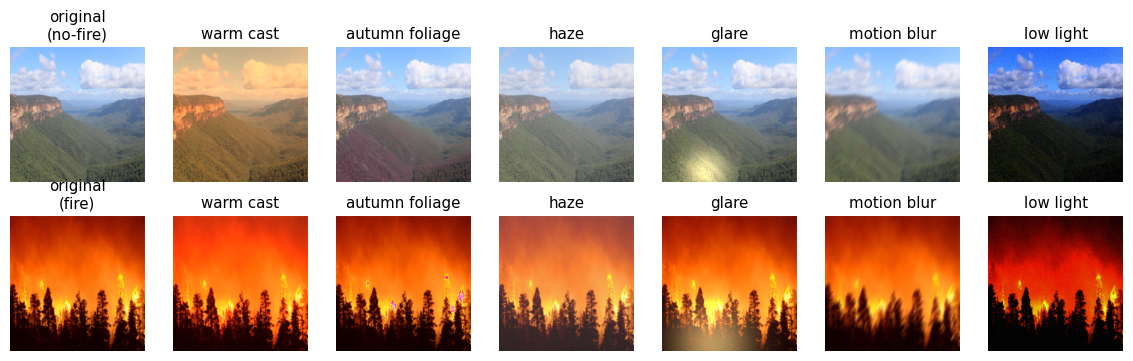

In [ ]:
#@title 7 · Augmentation pools (paper-1 copies + confounder-aware copies) and Figure 2
import matplotlib.pyplot as plt
pool = {}
t0 = time.time()
for kind, c in C.pool_blocks():
    f = os.path.join(P["tmp"], f"pool224_{kind}_{c}.npy")
    if os.path.exists(f):
        pool[f"{kind}_{c}"] = np.load(f, mmap_mode="r"); continue
    arr = C.make_block(X_tr, kind, c)
    np.save(f, arr); pool[f"{kind}_{c}"] = arr
    print("   built %-7s (%.1f min)" % (f"{kind}_{c}", (time.time() - t0) / 60))
C.save_json({k: C.fingerprint(np.asarray(v)) for k, v in pool.items()},
            os.path.join(P["data"], "pool_fingerprint.json"))
print("Pool blocks:", list(pool))

# Figure 2 — one example of every confounder transform
plt.rcParams.update({"font.size": 9, "font.family": "DejaVu Sans"})
ex = [int(np.where(D["tr_y"] == 0)[0][3]), int(np.where(D["tr_y"] == 1)[0][5])]
ops = [n for n, _ in C.CONF_OPS]
fig, ax = plt.subplots(2, len(ops) + 1, figsize=(1.65 * (len(ops) + 1), 3.6))
for r, i in enumerate(ex):
    ax[r, 0].imshow(X_tr[i]); ax[r, 0].set_title("original\n(%s)" % ("no-fire" if r == 0 else "fire"))
    for j, op in enumerate(ops):
        ax[r, j + 1].imshow(C.conf_one(X_tr[i], i, 1, force=op))
        ax[r, j + 1].set_title(op.replace("_", " "))
for a in ax.ravel():
    a.axis("off")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(P["figures"], "fig2_confounder_examples." + ext), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
#@title 8 · Teacher backbone features (DenseNet201 + MobileNetV3Large, frozen, ImageNet)
d_net, m_net = C.teacher_backbones()
BB = {"DenseNet201": (d_net, C.densenet_prep), "MobileNetV3Large": (m_net, C.mnv3_prep)}
sets = {**{k: v for k, v in pool.items()}, "val": X_va, "din": X_te, "wild": X_w, "dfire": X_f}
t0 = time.time()
for bname, (net, prep) in BB.items():
    for sname, arr in sets.items():
        f = os.path.join(P["features"], f"{bname}_{sname}.npy")
        if not os.path.exists(f):
            np.save(f, C.extract_features(net, prep, np.asarray(arr)))
    print("   %s done (%.1f min)" % (bname, (time.time() - t0) / 60))
def feats(sname):
    return [np.load(os.path.join(P["features"], f"{b}_{sname}.npy")) for b in BB]

12683000/12683000 [==============================] - 0s 0us/step
   DenseNet201 done (2.5 min)
   MobileNetV3Large done (3.4 min)


In [ ]:
#@title 9 · Train the MWAMNet heads — paper-1 protocol, 5 seeds
tblocks = [f"{k}_{c}" for k, c in C.teacher_blocks()]
Xtr_f = [np.concatenate([feats(b)[j] for b in tblocks]) for j in range(2)]
ytr = np.tile(D["tr_y"], len(tblocks)).astype("float32")
Xva_f, Xte_f = feats("val"), feats("din")
log_rows = []
for s in C.CFG["SEEDS"]:
    wf = os.path.join(P["models"], f"teacher_head_s{s}.weights.h5")
    if os.path.exists(wf):
        print("seed %d: cached" % s); continue
    m, ep = C.train_head(Xtr_f, ytr, Xva_f, D["va_y"].astype("float32"), s)
    m.save_weights(wf)
    pte = m.predict(Xte_f, verbose=0).ravel()
    acc = ((pte > .5) == D["te_y"]).mean()
    log_rows.append(dict(seed=s, epochs=ep, test_acc=acc)); print("seed %d: epochs %d  test acc %.4f" % (s, ep, acc))
    keras.backend.clear_session()
if log_rows:
    C.append_rows(os.path.join(P["results"], "teacher_train_log.csv"),
                  [dict(r, model_id=f"T_head_s{r['seed']}") for r in log_rows])

seed 42: epochs 24  test acc 0.9921
seed 43: epochs 17  test acc 0.9868
seed 44: epochs 28  test acc 0.9974
seed 45: epochs 20  test acc 0.9895
seed 46: epochs 17  test acc 0.9895


In [ ]:
#@title 10 · Teacher FP32 predictions, 5-seed ensemble and distillation soft labels
heads = {}
for s in C.CFG["SEEDS"]:
    h = C.build_head([Xtr_f[0].shape[1], Xtr_f[1].shape[1]])
    h.load_weights(os.path.join(P["models"], f"teacher_head_s{s}.weights.h5")); heads[s] = h
zmodels = {s: C.head_logit_model(heads[s]) for s in C.CFG["SEEDS"]}
def teacher_logits(sname):
    f = [tf.constant(a) for a in feats(sname)]
    return np.stack([np.concatenate([zmodels[s]([a[i:i + 1024] for a in f], training=False).numpy().ravel()
                                     for i in range(0, len(f[0]), 1024)]) for s in C.CFG["SEEDS"]])
sig = lambda z: 1 / (1 + np.exp(-z))
rows, Z = [], {}
for ds in C.EVALSETS:
    Z[ds] = teacher_logits(ds)
for i, s in enumerate(C.CFG["SEEDS"]):
    mid = f"T_fp32_s{s}"; pr = {ds: sig(Z[ds][i]) for ds in C.EVALSETS}
    meta = dict(family="teacher", arch="MWAMNet", res=224, regime="-", quant="fp32", seed=s)
    C.save_preds(P, mid, pr, meta); rows += C.metric_rows(P, mid, pr, meta)
pr = {ds: sig(Z[ds]).mean(0) for ds in C.EVALSETS}
meta = dict(family="teacher", arch="MWAMNet", res=224, regime="-", quant="fp32", seed="ens5")
C.save_preds(P, "T_fp32_ens", pr, meta); rows += C.metric_rows(P, "T_fp32_ens", pr, meta)
M = C.append_rows(os.path.join(P["results"], "metrics_nb1.csv"), rows)
# median seed by in-domain accuracy (paper-1 rule)
acc = {s: ((sig(Z["din"][i]) > .5) == D["te_y"]).mean() for i, s in enumerate(C.CFG["SEEDS"])}
order = sorted(C.CFG["SEEDS"], key=lambda s: (acc[s], s)); med = order[len(order) // 2]
C.save_json({"median_seed": med, "acc": acc}, os.path.join(P["data"], "teacher_median_seed.json"))
# soft labels: logit of the 5-seed mean probability, for every pool block
soft = {}
for b in pool:
    pz = sig(teacher_logits(b)).mean(0).clip(1e-6, 1 - 1e-6)
    soft[b] = np.log(pz / (1 - pz)).astype("float32")
np.savez(os.path.join(P["data"], "teacher_soft.npz"), **soft)
show = M[M.model_id.str.startswith("T_fp32")][["model_id", "dataset", "acc", "bacc", "recall", "auc", "ece"]]
print("Median seed:", med); print(show.round(4).to_string(index=False))

Median seed: 46
  model_id dataset    acc   bacc  recall    auc    ece
T_fp32_s42     din 0.9921 0.9921  0.9895 0.9998 0.0106
T_fp32_s42    wild 0.7468 0.7019  0.5024 0.7648 0.2178
T_fp32_s42   dfire 0.8093 0.8007  0.7704 0.8989 0.1600
T_fp32_s43     din 0.9868 0.9868  0.9895 0.9998 0.0202
T_fp32_s43    wild 0.7405 0.7210  0.6344 0.7779 0.1715
T_fp32_s43   dfire 0.8087 0.8392  0.9462 0.9166 0.1472
T_fp32_s44     din 0.9974 0.9974  1.0000 0.9998 0.0053
T_fp32_s44    wild 0.7454 0.7046  0.5234 0.7698 0.2162
T_fp32_s44   dfire 0.7894 0.7896  0.7901 0.8902 0.1740
T_fp32_s45     din 0.9895 0.9895  0.9895 0.9998 0.0135
T_fp32_s45    wild 0.7583 0.7151  0.5234 0.7873 0.1916
T_fp32_s45   dfire 0.8071 0.7699  0.6395 0.8557 0.1504
T_fp32_s46     din 0.9895 0.9895  0.9895 0.9998 0.0135
T_fp32_s46    wild 0.7465 0.6982  0.4842 0.7694 0.1825
T_fp32_s46   dfire 0.8244 0.8160  0.7865 0.9138 0.0939
T_fp32_ens     din 0.9921 0.9921  0.9947 0.9998 0.0142
T_fp32_ens    wild 0.7572 0.7146  0.5254 0.7780 0

In [ ]:
#@title 11 · Verify the end-to-end teacher (raw pixels -> P(fire)) against the feature path
med = C.load_json(os.path.join(P["data"], "teacher_median_seed.json"))["median_seed"]
T = C.build_teacher_e2e(os.path.join(P["models"], f"teacher_head_s{med}.weights.h5"), d_net, m_net)
n = 64
p_e2e = T.predict(X_te[:n].astype("float32"), verbose=0).ravel()
p_feat = heads[med].predict([f[:n] for f in feats("din")], verbose=0).ravel()
dmax = float(np.abs(p_e2e - p_feat).max())
print("max |P_e2e - P_features| on %d images = %.2e" % (n, dmax))
assert dmax < 1e-3, "End-to-end teacher differs from the feature path — do not continue."
print("Parameters (end-to-end):", T.count_params())

max |P_e2e - P_features| on 64 images = 1.01e-06
Parameters (end-to-end): 24811457


In [ ]:
#@title 12 · Teacher weight-only bit-width sweep (per-channel symmetric, 8 -> 3 bits)
rows = []
for b in C.CFG["WBITS"]:
    ids = [f"T_w{b}_s{s}" for s in C.CFG["SEEDS"]]
    if all(C.have_preds(P, i) for i in ids):
        print("%d-bit: cached" % b); continue
    bk = C.fake_quant_weights(d_net, b) + C.fake_quant_weights(m_net, b)
    fq = {ds: [C.extract_features(net, prep, {"din": X_te, "wild": X_w, "dfire": X_f}[ds])
               for net, prep in BB.values()] for ds in C.EVALSETS}
    C.restore_weights(bk)
    for s in C.CFG["SEEDS"]:
        hb = C.fake_quant_weights(heads[s], b)
        pr = {ds: heads[s].predict(fq[ds], verbose=0, batch_size=512).ravel() for ds in C.EVALSETS}
        C.restore_weights(hb)
        meta = dict(family="teacher", arch="MWAMNet", res=224, regime="-", quant=f"w{b}", seed=s)
        C.save_preds(P, f"T_w{b}_s{s}", pr, meta); rows += C.metric_rows(P, f"T_w{b}_s{s}", pr, meta)
    print("%d-bit done" % b)
if rows:
    C.append_rows(os.path.join(P["results"], "metrics_nb1.csv"), rows)
M = C.load_metrics(P)
t = M[M.family.eq("teacher") & M.seed.astype(str).ne("ens5")]
print(t.groupby(["quant", "dataset"])[["acc", "bacc", "recall"]].mean().round(4).to_string())

8-bit done
6-bit done
5-bit done
4-bit done
3-bit done
                  acc    bacc  recall
quant dataset                        
fp32  dfire    0.8078  0.8030  0.7865
      din      0.9911  0.9911  0.9916
      wild     0.7475  0.7082  0.5336
w3    dfire    0.6297  0.4974  0.0335
      din      0.4947  0.4947  0.0463
      wild     0.6041  0.5046  0.0630
w4    dfire    0.7483  0.7438  0.7283
      din      0.9479  0.9479  0.9695
      wild     0.6813  0.6363  0.4367
w5    dfire    0.8117  0.7955  0.7387
      din      0.9805  0.9805  0.9779
      wild     0.7256  0.6684  0.4147
w6    dfire    0.7915  0.7914  0.7910
      din      0.9874  0.9874  0.9958
      wild     0.7320  0.6943  0.5267
w8    dfire    0.8040  0.8010  0.7907
      din      0.9905  0.9905  0.9926
      wild     0.7480  0.7112  0.5481


In [ ]:
#@title 13 · Summary
print("Saved under", P["root"])
for sub in ("results", "figures", "data"):
    for f in sorted(os.listdir(P[sub])):
        print("  %s/%s" % (sub, f))

Saved under /content/drive/MyDrive/TinyMWAMNet
  results/leakage_audit.csv
  results/leakage_removed_files.json
  results/metrics_nb1.csv
  results/teacher_train_log.csv
  figures/fig2_confounder_examples.pdf
  figures/fig2_confounder_examples.png
  data/din_224.npz
  data/eval_224.npz
  data/labels.npz
  data/manifest.json
  data/pool_fingerprint.json
  data/teacher_median_seed.json
  data/teacher_soft.npz
